# Code Repurposed From XAI CODE DEMO (link below)

[![Open In Collab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/AIPI-590-XAI/Duke-AI-XAI/blob/dev/interpretable-ml-example-notebooks/generalized-models-interpretability.ipynb)

# Model Used

* Logistic Generalized Additive Models (Logistic GAM)

This model was chosen since the task at hand is one of classification and the output of the model should ideally resemble valid probabilities.

In [9]:
!pip install pygam --quiet
!pip install statsmodels --quiet


[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


In [10]:
# All imports kept as original

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from pathlib import Path
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report
from statsmodels.genmod.generalized_linear_model import GLM
from statsmodels.genmod.families import Gamma
from statsmodels.genmod.families.links import Log
from statsmodels.tools import add_constant
from pygam import LogisticGAM, s, f



#### Dataset

The full dataset is available over here: https://www.kaggle.com/datasets/blastchar/telco-customer-churn/data 

In [11]:
# Load the dataset
data_path = Path("data/raw.csv")
df = pd.read_csv(data_path)

# Convert churn and TotalCharges to numeric values
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)
df["TotalCharges"] = df["TotalCharges"].fillna(0)


# EDA 1 - Get big picture overview of churn 
churn_counts = df["Churn"].value_counts()
churn_rate = df["Churn"].mean()

print(churn_counts)
print(f"Overall churn rate: {churn_rate:.1%}")

Churn
0    5174
1    1869
Name: count, dtype: int64
Overall churn rate: 26.5%


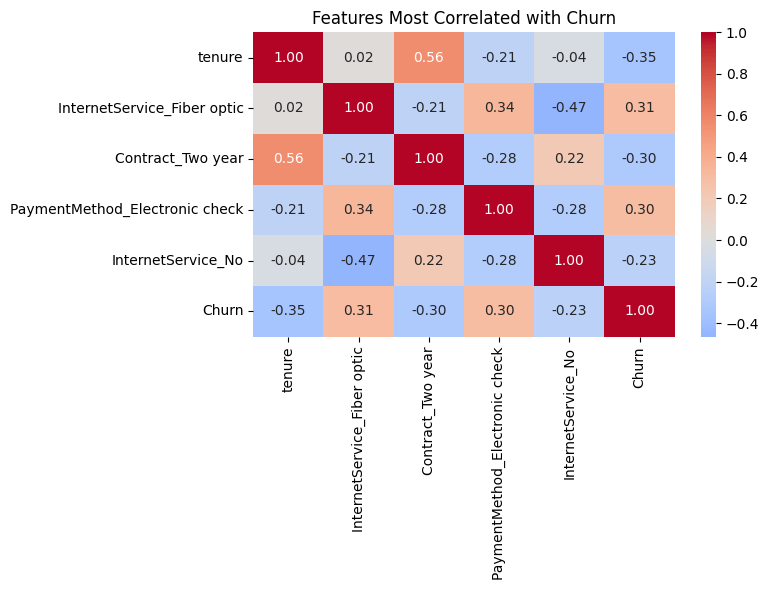

tenure                           -0.352229
InternetService_Fiber optic       0.308020
Contract_Two year                -0.302253
PaymentMethod_Electronic check    0.301919
InternetService_No               -0.227890
Name: Churn, dtype: float64


In [12]:
# EDA 2 - Simple correlations and feature selection

df_encoded = pd.get_dummies(
    df.drop(columns="customerID"),
    drop_first=True,
    dtype=int
)

# Calculate all correlations
correlations = df_encoded.corr()

# Select the top five features most strongly correlated with churn
top_features = (
    correlations["Churn"]
    .drop("Churn")
    .abs()
    .nlargest(5)
    .index
)

top_correlation_matrix = df_encoded[
    list(top_features) + ["Churn"]
].corr()

# Plot the results
plt.figure(figsize=(8, 6))

sns.heatmap(
    top_correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Features Most Correlated with Churn")
plt.tight_layout()
plt.show()

print(correlations.loc[top_features, "Churn"])


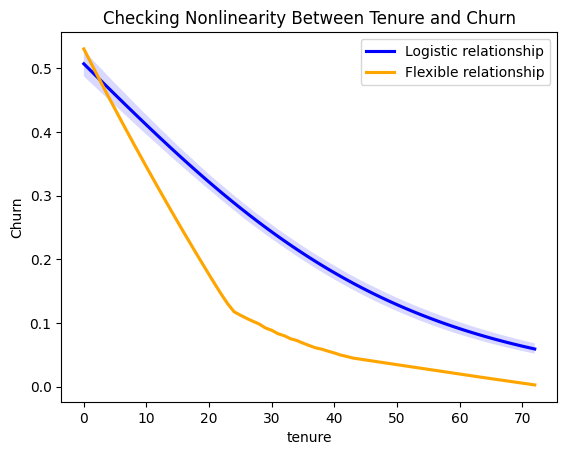

In [13]:
# Check non linearity for tenure
sns.regplot(data=df, x="tenure", y="Churn", logistic=True, scatter=False, label="Logistic relationship",
            line_kws={"label": "Logistic relationship", "color": "blue",})

sns.regplot(data=df, x="tenure", y="Churn", lowess=True, scatter=False, label="Flexible relationship",
            line_kws={"label": "Flexible relationship", "color": "orange",})

plt.title("Checking Nonlinearity Between Tenure and Churn")
plt.legend()
plt.show()  

# No need to check non-linearity for others since they are already categorical 

In [14]:
# Now we pick 
df["FiberOptic"] = (
    df["InternetService"] == "Fiber optic"
).astype(int)

df["TwoYearContract"] = (
    df["Contract"] == "Two year"
).astype(int)

df["ElectronicCheck"] = (
    df["PaymentMethod"] == "Electronic check"
).astype(int)

df["NoInternet"] = (
    df["InternetService"] == "No"
).astype(int)


# Only use the selected features for modeling
selected_features = [
    "tenure",
    "FiberOptic",
    "TwoYearContract",
    "ElectronicCheck",
    "NoInternet"
]

X = df[selected_features]
y = df["Churn"]


# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


# Convert to arrays
X_train_gam = X_train.to_numpy()
X_test_gam = X_test.to_numpy()

## Logistic Generalized Additive Model (GAM)

* GAMs assume that the outcome can be modeled by a sum of arbitrary functions of each feature
* GAMs use B splines, which allow us to automatically model non-linear relationships
* GAM is still a sum of feature effects, but it gives the option to allow nonlinear relationships between some features and the output

In [15]:
# Initilize GAM
gam = LogisticGAM(s(0) + f(1) + f(2) + f(3) + f(4))

# Find best smoothing parameters for each spline term
gam.gridsearch(
    X_train_gam,
    y_train.to_numpy(),
    progress=False
)

# Predict churn probabilities
y_prob_gam = gam.predict_proba(X_test_gam)


# Convert probabilities into 0/1 predictions
y_pred_gam = (y_prob_gam >= 0.5).astype(int)


# Evaluate the model
accuracy_gam = accuracy_score(y_test, y_pred_gam)
auc_gam = roc_auc_score(y_test, y_prob_gam)

print(f"GAM Accuracy: {accuracy_gam:.4f}")
print(f"GAM ROC-AUC: {auc_gam:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_gam))


# Display model details
gam.summary()

GAM Accuracy: 0.7871
GAM ROC-AUC: 0.8368

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.91      0.86      1035
           1       0.65      0.44      0.52       374

    accuracy                           0.79      1409
   macro avg       0.73      0.68      0.69      1409
weighted avg       0.77      0.79      0.77      1409

LogisticGAM                                                                                               
=============================================== ==========================================================
Distribution:                      BinomialDist Effective DoF:                                     16.5083
Link Function:                        LogitLink Log Likelihood:                                 -2379.1913
Number of Samples:                         5634 AIC:                                             4791.3992
                                                AICc:                    

/var/folders/dw/y0ppggnd38ldw3_q4mtjh92w0000gn/T/ipykernel_73883/3071877734.py:31: UserWarning: KNOWN BUG: p-values computed in this summary are likely much smaller than they should be. 
 
Please do not make inferences based on these values! 

Collaborate on a solution, and stay up to date at: 
github.com/dswah/pyGAM/issues/163 

  gam.summary()


### GAM - Partial Dependence Plots
Plots the partial dependence of each feature, showing the effect of each feature on the predicted outcome while holding other features constant.

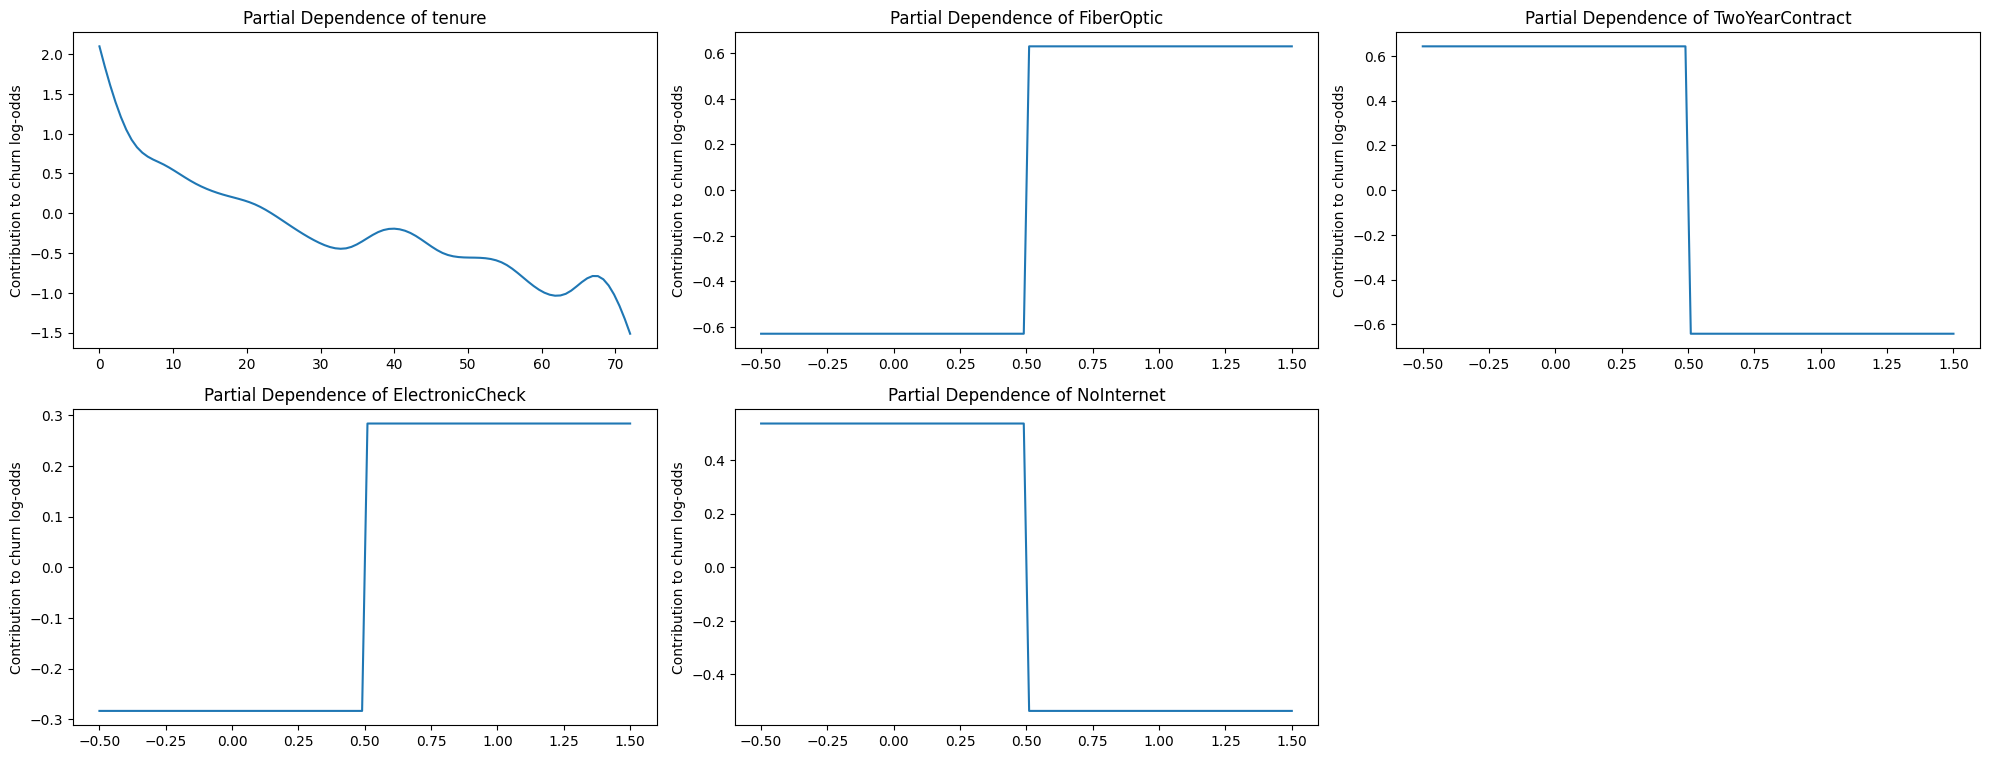

In [16]:
# Visualize GAM
plt.figure(figsize=(20, 15))
for i, term in enumerate(gam.terms):
    if term.isintercept:
        continue
    plt.subplot(4, 3, i+1)
    XX = gam.generate_X_grid(term=i)
    plt.plot(XX[:, term.feature], gam.partial_dependence(term=i, X=XX))
    plt.title(f"Partial Dependence of {selected_features[i]}")
    plt.ylabel("Contribution to churn log-odds")
plt.tight_layout()
plt.show()

### Smooth Effect Interpretation

Of the features selected, based on correlation with Churn, only tenure is continuous and does indeed vary with the target variable in a non-linear fashion. The fitted model seems justifiably accurate (~79%) with ~0.84 ROC-AUC. We see that customers with very low tenure are disproportionately more likely to churn, whereas the relation fluctuates as the tenure progresses to much higher values. Considering that these fluctuations might also include noise or overfitting, we do not overinterpret them. 

### One Limitation

The various features in this dataset almost certainly interact with each other. For instance, new users using the fiber service might have a very different decision calculus than the ones with longer tenures - but that interaction cannot be captured by the individual splines in our GAM.